# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Aulia Alfiana
- **Email:** auliaalff111@gmail.com
- **ID Dicoding:** CDCC123D6X0293

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:** “Bagaimana pengaruh keterlambatan pengiriman terhadap penurunan rata-rata review score pelanggan sebesar minimal 1 poin pada transaksi e-commerce Olist selama periode tahun 2017–2018?”

SMART Analysis
* Specific: Fokus pada hubungan keterlambatan pengiriman dan review score pelanggan
* Measurable: Mengukur penurunan review score sebesar minimal 1 poin
* Action-Oriented: Hasil analisis dapat digunakan untuk memperbaiki sistem logistik dan pengiriman
* Relevant: Kepuasan pelanggan sangat penting dalam bisnis e-commerce
* Time-bound: Dibatasi pada periode transaksi tahun 2017–2018

**Pertanyaan 2:** “Kategori produk apa yang mengalami penurunan total penjualan lebih dari 10% dan memiliki rata-rata review score di bawah 4 selama periode tahun 2017–2018 pada platform Olist?”

SMART Analysis
* Specific: Fokus pada kategori produk dengan penjualan menurun dan review rendah
* Measurable: Penurunan penjualan lebih dari 10% dan review score di bawah 4
* Action-Oriented: Hasil dapat digunakan untuk meningkatkan kualitas produk dan strategi pemasaran
* Relevant: Penjualan dan kepuasan pelanggan sangat memengaruhi profit bisnis
* Time-bound: Periode tahun 2017–2018

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# PENGATURAN VISUALISASI
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

## Data Wrangling

### Gathering Data

In [2]:
# MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

# PATH DATASET
data_dir = "/content/drive/MyDrive/Dicoding/E-Commerce Public Dataset"

# LOAD DATASET
customers_df = pd.read_csv(f"{data_dir}/olist_customers_dataset.csv")
orders_df = pd.read_csv(f"{data_dir}/olist_orders_dataset.csv")
order_items_df = pd.read_csv(f"{data_dir}/olist_order_items_dataset.csv")
products_df = pd.read_csv(f"{data_dir}/olist_products_dataset.csv")
reviews_df = pd.read_csv(f"{data_dir}/olist_order_reviews_dataset.csv")
translation_df = pd.read_csv(f"{data_dir}/product_category_name_translation.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Load df ...

In [3]:
# MENAMPILKAN DATASET
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [6]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:** (Opsional)

Dataset yang digunakan terdiri dari data transaksi e-commerce Olist periode 2016–2018 yang mencakup informasi pelanggan, transaksi, pengiriman, review pelanggan, detail produk, dan kategori produk.

Dataset orders_dataset dan order_reviews_dataset menjadi dataset utama untuk menjawab pertanyaan bisnis pertama karena memuat informasi tanggal pengiriman serta review score pelanggan.

Sedangkan kombinasi order_items_dataset, products_dataset, dan product_category_name_translation digunakan untuk menganalisis performa kategori produk berdasarkan total penjualan dan review score pada pertanyaan bisnis kedua.


### Assessing Data

#### Identifying ... problem

In [9]:
# MENGECEK INFORMASI DATASET
datasets = {
    'customers': customers_df,
    'orders': orders_df,
    'reviews': reviews_df,
    'order_items': order_items_df,
    'products': products_df,
    'translation': translation_df
}

for name, df in datasets.items():
    print(f'===== {name.upper()} =====')
    print(df.info())
    print('\n')

===== CUSTOMERS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None


===== ORDERS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_pu

In [10]:
# MENGECEK MISSING VALUE
for name, df in datasets.items():
    print(f'===== {name.upper()} =====')
    print(df.isna().sum())
    print('\n')

===== CUSTOMERS =====
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


===== ORDERS =====
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


===== REVIEWS =====
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


===== ORDER_ITEMS =====
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int

In [11]:
# MENGECEK DUPLICATE DATA
for name, df in datasets.items():
    print(f'===== {name.upper()} =====')
    print('Duplicate:', df.duplicated().sum())
    print('\n')

===== CUSTOMERS =====
Duplicate: 0


===== ORDERS =====
Duplicate: 0


===== REVIEWS =====
Duplicate: 0


===== ORDER_ITEMS =====
Duplicate: 0


===== PRODUCTS =====
Duplicate: 0


===== TRANSLATION =====
Duplicate: 0




**Insight:** (Opsional)

- Hasil pengecekan data menunjukkan adanya missing value pada kolom order_delivered_customer_date sebanyak 2.965 data dan product_category_name sebanyak 610 data.
- Missing value pada order_delivered_customer_date perlu ditangani karena kolom tersebut digunakan untuk menghitung keterlambatan pengiriman pada pertanyaan bisnis pertama.
- Selain itu, tipe data tanggal pada dataset orders masih berbentuk object sehingga perlu dikonversi menjadi datetime agar analisis berbasis waktu tahun 2017–2018 dapat dilakukan dengan akurat.
- Tidak ditemukan duplicate data pada seluruh dataset sehingga proses analisis dapat dilakukan tanpa risiko duplikasi perhitungan.


### Cleaning Data

#### Fixing ... problem

In [12]:
# MENGHAPUS MISSING VALUE
orders_df = orders_df.dropna(
    subset=['order_delivered_customer_date']
).copy()

products_df = products_df.dropna(
    subset=['product_category_name']
).copy()

reviews_df = reviews_df.dropna(
    subset=['review_comment_message']
).copy()

In [13]:
# MENGHAPUS DUPLICATE DATA
customers_df = customers_df.drop_duplicates()
orders_df = orders_df.drop_duplicates()
reviews_df = reviews_df.drop_duplicates()
order_items_df = order_items_df.drop_duplicates()
products_df = products_df.drop_duplicates()
translation_df = translation_df.drop_duplicates()

In [14]:
# KONVERSI DATETIME
datetime_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Filter hanya transaksi tahun 2017-2018
orders_filtered_df = orders_df[
    orders_df["order_purchase_timestamp"].dt.year.isin([2017, 2018])
].copy()

orders_filtered_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


**Insight:** (Opsional)

- Proses cleaning dilakukan dengan menghapus data yang tidak relevan terhadap analisis bisnis.
- Sebanyak 2.965 data transaksi tanpa tanggal pengiriman dihapus karena tidak dapat digunakan untuk menghitung delivery delay.
- Sebanyak 610 data produk tanpa kategori juga dihapus agar seluruh transaksi produk dapat dianalisis berdasarkan kategori produk secara valid.
- Konversi tipe data datetime berhasil dilakukan pada kolom waktu transaksi dan pengiriman sehingga analisis periode tahun 2017–2018 dapat dilakukan secara lebih akurat.


## Exploratory Data Analysis (EDA)

### Explore Question 1

In [15]:
# MERGE DATASET
delivery_review_df = orders_filtered_df.merge(
    reviews_df,
    on="order_id",
    how="inner"
)

delivery_review_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
3,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,15898b543726a832d4137fbef5d1d00e,1,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47
4,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-02 21:09:20,2018-03-12 23:36:26,2018-03-21,8f39f09c22b1ceb6e3eb178d8e50bb8a,4,NaN,Gostei do produto,2018-03-13 00:00:00,2018-03-14 10:36:16


In [16]:
# MENGHITUNG DELAY PENGIRIMAN
delivery_review_df["delivery_delay"] = (
    delivery_review_df["order_delivered_customer_date"] -
    delivery_review_df["order_estimated_delivery_date"]
).dt.days

In [17]:
# MEMBUAT STATUS PENGIRIMAN
delivery_review_df["delivery_status"] = np.where(
    delivery_review_df["delivery_delay"] > 0,
    "Late",
    "On Time"
)

delivery_review_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,-8,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,-6,On Time
2,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,-13,On Time
3,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,15898b543726a832d4137fbef5d1d00e,1,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47,-9,On Time
4,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-02 21:09:20,2018-03-12 23:36:26,2018-03-21,8f39f09c22b1ceb6e3eb178d8e50bb8a,4,NaN,Gostei do produto,2018-03-13 00:00:00,2018-03-14 10:36:16,-9,On Time


In [18]:
# MENGHAPUS MISSING VALUE
delivery_review_df = delivery_review_df.dropna(
    subset=["delivery_delay", "review_score"]
)

In [19]:
# RATA-RATA REVIEW BERDASARKAN STATUS PENGIRIMAN
review_comparison_df = delivery_review_df.groupby(
    "delivery_status"
)["review_score"].mean().reset_index()

review_comparison_df

,delivery_status,review_score
0,Late,1.920180
1,On Time,3.972138


In [20]:
# MENGUKUR PENURUNAN REVIEW SCORE
on_time_review = review_comparison_df[
    review_comparison_df["delivery_status"] == "On Time"
]["review_score"].values[0]

late_review = review_comparison_df[
    review_comparison_df["delivery_status"] == "Late"
]["review_score"].values[0]

review_drop = on_time_review - late_review

print("Rata-rata review tepat waktu :", round(on_time_review, 2))
print("Rata-rata review terlambat :", round(late_review, 2))
print("Penurunan review score :", round(review_drop, 2), "poin")

Rata-rata review tepat waktu : 3.97
Rata-rata review terlambat : 1.92
Penurunan review score : 2.05 poin


In [21]:
# ANALISIS TREN BERDASARKAN TINGKAT KETERLAMBATAN
bins = [-100, 0, 3, 7, 14, 30, 100]
labels = [
    "On Time",
    "1-3 Days",
    "4-7 Days",
    "8-14 Days",
    "15-30 Days",
    ">30 Days"
]

delivery_review_df["delay_group"] = pd.cut(
    delivery_review_df["delivery_delay"],
    bins=bins,
    labels=labels
)

delay_group_df = delivery_review_df.groupby(
    "delay_group"
)["review_score"].mean().reset_index()

delay_group_df

/tmp/ipykernel_28862/1697700156.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_group_df = delivery_review_df.groupby(


,delay_group,review_score
0,On Time,3.972165
1,1-3 Days,2.785714
2,4-7 Days,1.809933
3,8-14 Days,1.554140
4,15-30 Days,1.515742
5,>30 Days,1.637755


### Explore Question 2

In [22]:
# MERGE DATASET PRODUK
sales_review_df = orders_filtered_df.merge(
    order_items_df,
    on="order_id",
    how="inner"
)

sales_review_df = sales_review_df.merge(
    products_df,
    on="product_id",
    how="left"
)

sales_review_df = sales_review_df.merge(
    translation_df,
    on="product_category_name",
    how="left"
)

sales_review_df = sales_review_df.merge(
    reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

sales_review_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,NaN


In [23]:
# MENAMBAHKAN KOLOM TAHUN TRANSAKSI
sales_review_df["year"] = sales_review_df[
    "order_purchase_timestamp"
].dt.year

In [24]:
# MENGHITUNG TOTAL PENJUALAN PER TAHUN
sales_per_year_df = sales_review_df.groupby(
    ["product_category_name_english", "year"]
)["price"].sum().reset_index()

sales_per_year_df.head()

,product_category_name_english,year,price
0,agro_industry_and_commerce,2017,29179.20
1,agro_industry_and_commerce,2018,41386.90
2,air_conditioning,2017,27269.21
3,air_conditioning,2018,24705.06
4,art,2017,8981.34


In [25]:
# MEMBANDINGKAN PENJUALAN 2017 VS 2018
sales_comparison_df = sales_per_year_df.pivot_table(
    index="product_category_name_english",
    columns="year",
    values="price",
    fill_value=0
).reset_index()

sales_comparison_df.columns.name = None

sales_comparison_df = sales_comparison_df.rename(
    columns={
        2017: "sales_2017",
        2018: "sales_2018"
    }
)

sales_comparison_df.head()

,product_category_name_english,sales_2017,sales_2018
0,agro_industry_and_commerce,29179.20,41386.90
1,air_conditioning,27269.21,24705.06
2,art,8981.34,14675.96
3,arts_and_craftmanship,151.89,1662.12
4,audio,17452.67,32960.94


In [26]:
# MENGHITUNG PERSENTASE PERUBAHAN PENJUALAN
sales_comparison_df["sales_change_pct"] = (
    (
        sales_comparison_df["sales_2018"] -
        sales_comparison_df["sales_2017"]
    )
    /
    sales_comparison_df["sales_2017"]
) * 100

sales_comparison_df.head()

,product_category_name_english,sales_2017,sales_2018,sales_change_pct
0,agro_industry_and_commerce,29179.20,41386.90,41.836993
1,air_conditioning,27269.21,24705.06,-9.403096
2,art,8981.34,14675.96,63.405015
3,arts_and_craftmanship,151.89,1662.12,994.291922
4,audio,17452.67,32960.94,88.859011


In [27]:
#MENGHTIUNG RATA-RATA REVIEW PER KATEGORI
avg_review_df = sales_review_df.groupby(
    "product_category_name_english"
)["review_score"].mean().reset_index()

avg_review_df = avg_review_df.rename(
    columns={"review_score": "avg_review_score"}
)

avg_review_df.head()

,product_category_name_english,avg_review_score
0,agro_industry_and_commerce,3.573770
1,air_conditioning,3.394737
2,art,3.604651
3,arts_and_craftmanship,3.416667
4,audio,3.406250


In [28]:
# MENGGABUNGKAN SELURUH HASIL
final_category_df = sales_comparison_df.merge(
    avg_review_df,
    on="product_category_name_english",
    how="left"
)

final_category_df.head()

,product_category_name_english,sales_2017,sales_2018,sales_change_pct,avg_review_score
0,agro_industry_and_commerce,29179.20,41386.90,41.836993,3.573770
1,air_conditioning,27269.21,24705.06,-9.403096,3.394737
2,art,8981.34,14675.96,63.405015,3.604651
3,arts_and_craftmanship,151.89,1662.12,994.291922,3.416667
4,audio,17452.67,32960.94,88.859011,3.406250


In [29]:
# FILTERING SESUAI BUSINESS QUESTION
problematic_category_df = final_category_df[
    (final_category_df["sales_change_pct"] < -10) &
    (final_category_df["avg_review_score"] < 4)
].sort_values(by="sales_change_pct")

problematic_category_df

,product_category_name_english,sales_2017,sales_2018,sales_change_pct,avg_review_score
61,security_and_services,283.29,0.00,-100.000000,2.500000
67,tablets_printing_image,6260.45,1267.96,-79.746504,3.689655
46,home_comfort_2,609.18,151.09,-75.197807,3.500000
30,fashion_male_clothing,8125.56,2301.87,-71.671245,3.304348
27,fashio_female_clothing,1963.38,616.66,-68.591918,3.500000
25,dvds_blu_ray,3409.88,1132.71,-66.781529,3.789474
33,fashion_underwear_beach,6896.85,2409.10,-65.069561,3.814815
54,market_place,19314.91,7565.57,-60.830415,3.432432
47,home_confort,37360.70,20737.65,-44.493412,3.485597
69,toys,299056.71,168024.18,-43.815278,3.802020


**Insight:** (Opsional)
1. EDA Pertanyaan 1:
   - Hasil exploratory data analysis menunjukkan bahwa keterlambatan pengiriman memiliki pengaruh signifikan terhadap penurunan review score pelanggan pada transaksi tahun 2017–2018.
   - Rata-rata review score untuk pengiriman tepat waktu adalah sebesar 3.97, sedangkan transaksi yang mengalami keterlambatan hanya memperoleh rata-rata review score sebesar 1.92.
   - Hal ini menunjukkan adanya penurunan review score sebesar 2.05 poin akibat keterlambatan pengiriman, sehingga telah melebihi target penurunan minimal 1 poin pada business question.
   - Selain itu, hasil pengelompokan delivery delay menunjukkan bahwa semakin lama keterlambatan pengiriman, rata-rata review score pelanggan cenderung semakin rendah.

2. EDA Pertanyaan 2:
   - Hasil analisis kategori produk menunjukkan bahwa hanya kategori dengan penurunan penjualan lebih dari 10% dan rata-rata review score di bawah 4 yang dipilih sesuai business question.
   - Analisis dilakukan dengan membandingkan total penjualan kategori produk antara tahun 2017 dan 2018, kemudian menghitung persentase perubahan penjualan tiap kategori.
   - Kategori yang memenuhi kedua kondisi tersebut menunjukkan adanya hubungan antara rendahnya kepuasan pelanggan dengan penurunan performa penjualan produk pada platform Olist selama periode 2017–2018.


## Visualization & Explanatory Analysis

### Pertanyaan 1:

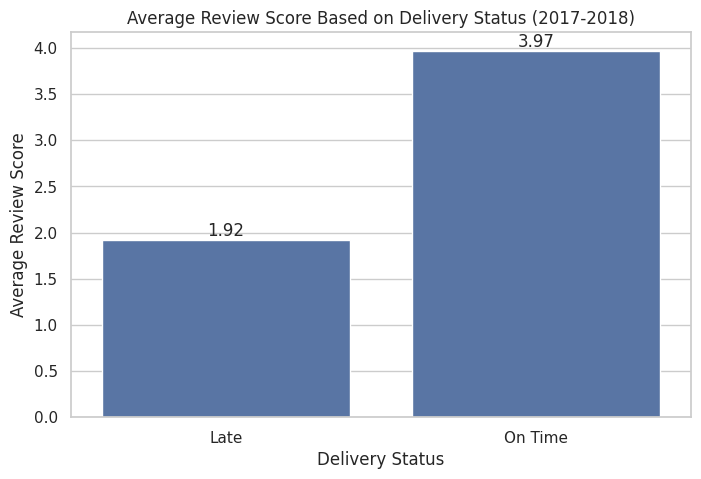

In [30]:
# Visualisasi 1 — Perbandingan Review Tepat Waktu vs Terlambat
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=review_comparison_df,
    x="delivery_status",
    y="review_score"
)

plt.title("Average Review Score Based on Delivery Status (2017-2018)")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

plt.show()

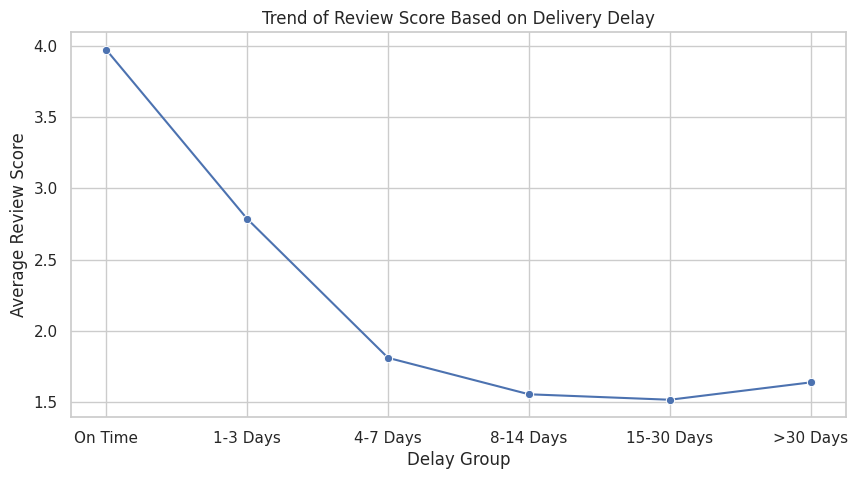

In [31]:
# Visualisasi 2 — Tren Review Berdasarkan Kelompok Keterlambatan
plt.figure(figsize=(10,5))

sns.lineplot(
    data=delay_group_df,
    x="delay_group",
    y="review_score",
    marker="o"
)

plt.title("Trend of Review Score Based on Delivery Delay")
plt.xlabel("Delay Group")
plt.ylabel("Average Review Score")

plt.show()

### Pertanyaan 2:

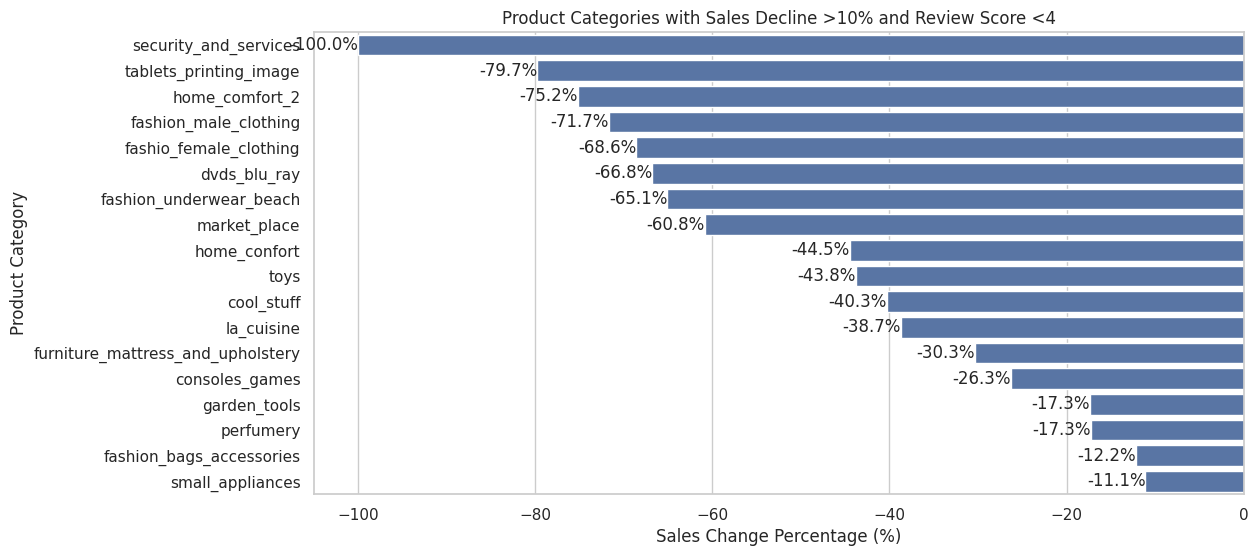

In [32]:
# Visualisasi 1 — Penurunan Penjualan >10%
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=problematic_category_df,
    x="sales_change_pct",
    y="product_category_name_english"
)

plt.title("Product Categories with Sales Decline >10% and Review Score <4")
plt.xlabel("Sales Change Percentage (%)")
plt.ylabel("Product Category")

for i in ax.containers:
    ax.bar_label(i, fmt="%.1f%%")

plt.show()

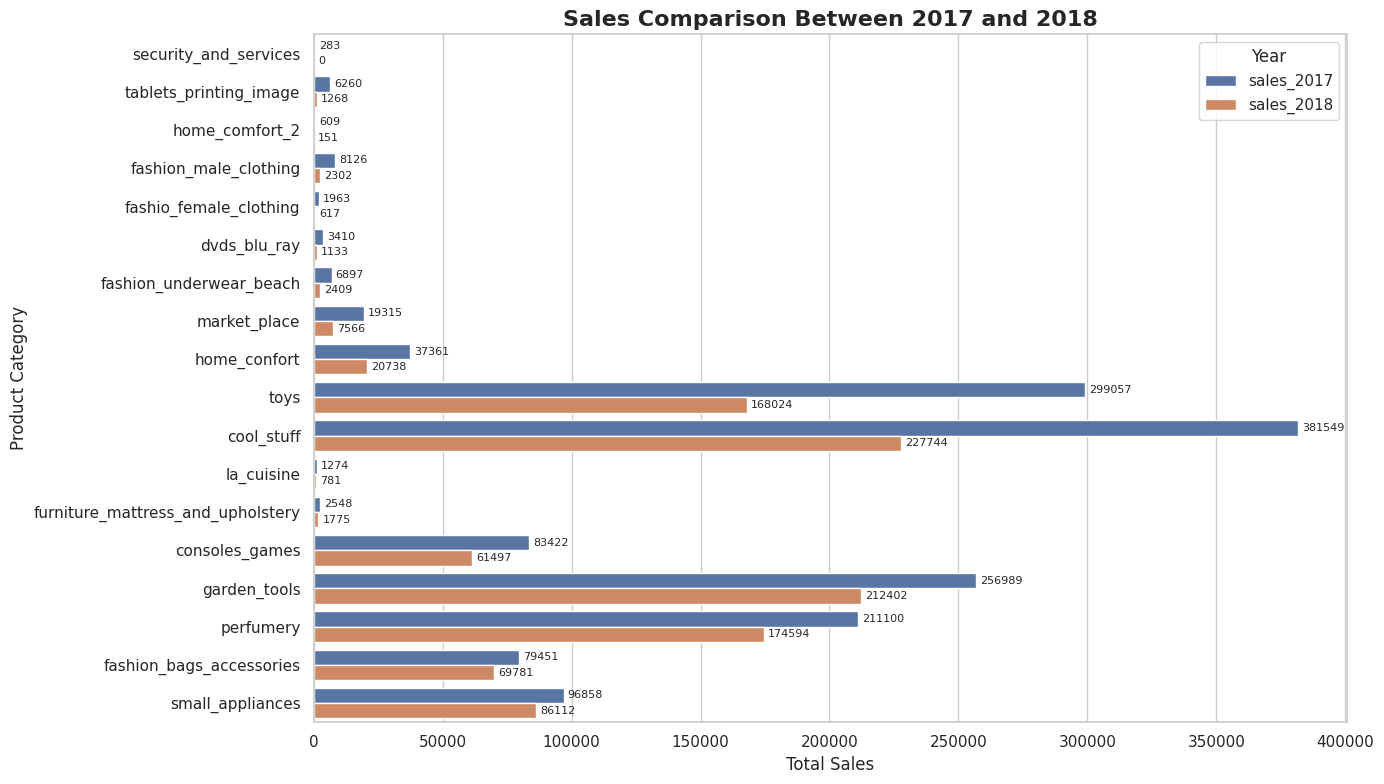

In [33]:
# Visualisasi 2 — Perbandingan Penjualan 2017 VS 2018

comparison_sales_df = problematic_category_df.melt(
    id_vars="product_category_name_english",
    value_vars=["sales_2017", "sales_2018"],
    var_name="year",
    value_name="sales"
)

# Urutkan kategori berdasarkan penurunan terbesar
category_order = problematic_category_df.sort_values(
    by="sales_change_pct"
)["product_category_name_english"]

plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=comparison_sales_df,
    y="product_category_name_english",
    x="sales",
    hue="year",
    order=category_order
)

plt.title(
    "Sales Comparison Between 2017 and 2018",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Product Category")

ax.ticklabel_format(style='plain', axis='x')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8
    )

plt.legend(title="Year")

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Visualisasi Pertanyaan 1: Visualisasi perbandingan rata-rata review score menunjukkan bahwa pengiriman tepat waktu memperoleh rata-rata review sebesar 3.97, sedangkan pengiriman terlambat hanya memperoleh rata-rata review sebesar 1.92. Perbedaan sebesar 2.05 poin menunjukkan bahwa keterlambatan pengiriman memberikan dampak signifikan terhadap kepuasan pelanggan. Selain itu, visualisasi tren berdasarkan kelompok keterlambatan menunjukkan bahwa rata-rata review score terus menurun seiring bertambahnya durasi keterlambatan pengiriman.

- Visualisasi Pertanyaan 2: Visualisasi menunjukkan beberapa kategori produk mengalami penurunan total penjualan lebih dari 10% dari tahun 2017 ke 2018 dan memiliki rata-rata review score di bawah 4. Grafik perbandingan penjualan tahun 2017 dan 2018 memperlihatkan adanya penurunan performa penjualan pada kategori-kategori tersebut. Hasil ini menunjukkan bahwa kategori dengan tingkat kepuasan pelanggan yang rendah cenderung mengalami penurunan performa penjualan pada platform Olist.

  - Kategori 'security_and_services' mengalami penurunan penjualan sebesar 100.00% dengan rata-rata review score 2.50
  - Kategori 'tablets_printing_image' mengalami penurunan penjualan sebesar 79.75% dengan rata-rata review score 3.69
  - Kategori 'home_comfort_2' mengalami penurunan penjualan sebesar 75.20% dengan rata-rata review score 3.50
  - Kategori 'fashion_male_clothing' mengalami penurunan penjualan sebesar 71.67% dengan rata-rata review score 3.30
  - Kategori 'fashio_female_clothing' mengalami penurunan penjualan sebesar 68.59% dengan rata-rata review score 3.50
  - Kategori 'dvds_blu_ray' mengalami penurunan penjualan sebesar 66.78% dengan rata-rata review score 3.79
  - Kategori 'fashion_underwear_beach' mengalami penurunan penjualan sebesar 65.07% dengan rata-rata review score 3.81
  - Kategori 'market_place' mengalami penurunan penjualan sebesar 60.83% dengan rata-rata review score 3.43
  - Kategori 'home_confort' mengalami penurunan penjualan sebesar 44.49% dengan rata-rata review score 3.49
  - Kategori 'toys' mengalami penurunan penjualan sebesar 43.82% dengan rata-rata review score 3.80
  - Kategori 'cool_stuff' mengalami penurunan penjualan sebesar 40.31% dengan rata-rata review score 3.90
  - Kategori 'la_cuisine' mengalami penurunan penjualan sebesar 38.70% dengan rata-rata review score 3.00
  - Kategori 'furniture_mattress_and_upholstery' mengalami penurunan penjualan sebesar 30.34% dengan rata-rata review score 3.50
  - Kategori 'consoles_games' mengalami penurunan penjualan sebesar 26.28% dengan rata-rata review score 3.71
  - Kategori 'garden_tools' mengalami penurunan penjualan sebesar 17.35% dengan rata-rata review score 3.73
  - Kategori 'perfumery' mengalami penurunan penjualan sebesar 17.29% dengan rata-rata review score 3.83
  - Kategori 'fashion_bags_accessories' mengalami penurunan penjualan sebesar 12.17% dengan rata-rata review score 3.93
  - Kategori 'small_appliances' mengalami penurunan penjualan sebesar 11.09% dengan rata-rata review score 3.89

   Kategori dengan review rendah cenderung mengalami penurunan penjualan yang signifikan.

## Analisis Lanjutan (Opsional)

In [34]:
# RFM ANALYSIS
rfm_df = orders_df.groupby('customer_id').agg({
    'order_purchase_timestamp':'max',
    'order_id':'count'
})

rfm_df.columns = ['last_order','frequency']

rfm_df['recency'] = (
    orders_df['order_purchase_timestamp'].max()
    -
    rfm_df['last_order']
).dt.days

rfm_df.head()

,last_order,frequency,recency
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,287
000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,409
0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,547
0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,378
000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,149


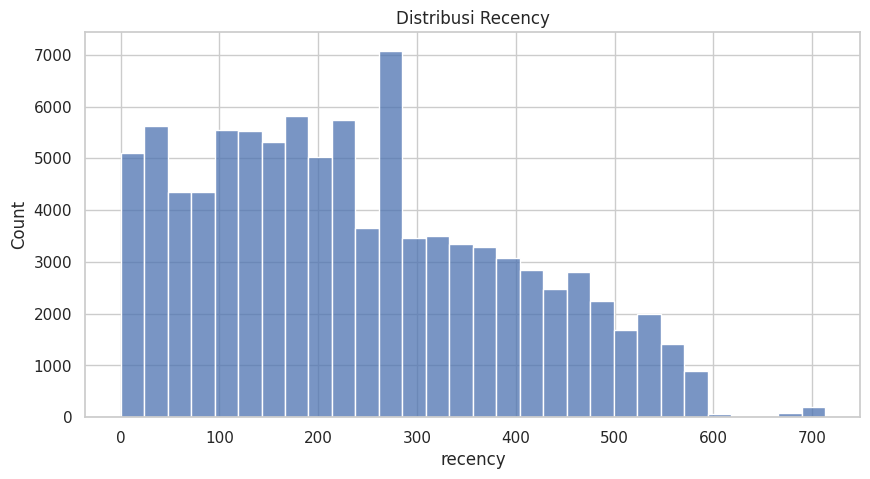

In [35]:
# VISUALISASI RECENCY
sns.histplot(rfm_df['recency'], bins=30)

plt.title('Distribusi Recency')
plt.show()

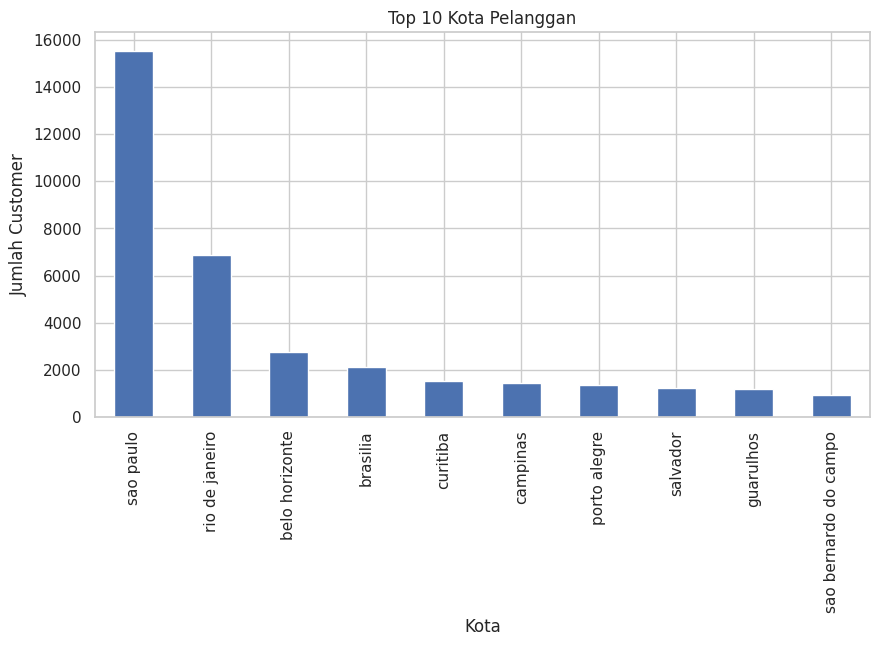

In [36]:
# GEOSPATIAL ANALYSIS
customer_city = customers_df[
    'customer_city'
].value_counts().head(10)

customer_city.plot(kind='bar')

plt.title('Top 10 Kota Pelanggan')
plt.xlabel('Kota')
plt.ylabel('Jumlah Customer')

plt.show()

**Insight:** (Opsional)
- Insight RFM Analysis

  RFM Analysis digunakan untuk memahami perilaku pelanggan berdasarkan:
  1. Recency: seberapa baru pelanggan melakukan transaksi,
  2. Frequency: seberapa sering pelanggan melakukan transaksi,
  3. Monetary/Frequency: jumlah aktivitas pembelian pelanggan.
  
  Analisis ini dapat membantu perusahaan mengidentifikasi pelanggan aktif dan loyal sehingga strategi pemasaran dapat dilakukan lebih efektif.

- Insight Geospatial Analysis

  Distribusi pelanggan menunjukkan bahwa terdapat beberapa kota dengan jumlah pelanggan yang jauh lebih tinggi dibanding wilayah lainnya. Informasi ini dapat dimanfaatkan perusahaan untuk menentukan strategi pemasaran, distribusi logistik, dan prioritas pengembangan layanan pada wilayah dengan jumlah pelanggan terbesar.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis transaksi Olist tahun 2017–2018, keterlambatan pengiriman terbukti menurunkan rata-rata review score pelanggan secara signifikan. Pengiriman tepat waktu memiliki rata-rata review score sebesar 3.97, sedangkan pengiriman terlambat hanya memperoleh rata-rata review sebesar 1.92. Dengan demikian, keterlambatan pengiriman menyebabkan penurunan review score sebesar 2.05 poin, sehingga telah melebihi target penurunan minimal 1 poin pada business question. Selain itu, semakin lama keterlambatan pengiriman, rata-rata review pelanggan cenderung semakin rendah.

- **Conclusion pertanyaan 2:** Berdasarkan hasil analisis tahun 2017–2018, ditemukan beberapa kategori produk yang mengalami penurunan total penjualan lebih dari 10% dan memiliki rata-rata review score di bawah 4. Kategori-kategori tersebut menunjukkan adanya indikasi bahwa rendahnya kepuasan pelanggan berhubungan dengan penurunan performa penjualan produk. Hasil analisis ini dapat digunakan perusahaan untuk memprioritaskan evaluasi kualitas produk, layanan seller, dan strategi pemasaran pada kategori produk dengan performa yang menurun.


**Rekomendasi Action Item:**
1. Mengoptimalkan performa logistik pada transaksi dengan tingkat keterlambatan tinggi karena keterlambatan terbukti menurunkan review score hingga 2.05 poin.
2. Melakukan monitoring terhadap seller dengan tingkat keterlambatan pengiriman tinggi untuk menjaga kepuasan pelanggan.
3. Mengevaluasi kategori produk yang mengalami penurunan penjualan lebih dari 10% dan memiliki review score di bawah 4.
4. Meningkatkan kualitas produk dan layanan pada kategori dengan review rendah agar performa penjualan dapat kembali meningkat.
5. Memberikan estimasi pengiriman yang lebih akurat untuk mengurangi potensi review negatif akibat keterlambatan.
